# Spectral Clustering


In this exercise, you will implement spectral clustering and try it on diffent kinds of data, for instance:

* N-blob: Random points in $\mathbb{R}^2$ according to N Gaussian distributions with different means;

* Two moons: Random points shaped as two intertwined moons; 

* Point and circle: random points from a concentrated Gaussian point in the middle and a wide circle around it.

The first step after generating the data is to construct a graph and, for that, we need a similarity function. In this exercise we will use the following similarity:

$$
d(x_i, x_j) = \exp\left(-\frac{||x_i-x_j||_2^2}{2\sigma^2}\right)
$$

Using this similarity, we can compute the weight matrix W representing the graph, compute the graph Laplacian L and finally use its eigenvectors for clustering.


## Setup

In [1]:
import os

from generate_data import worst_case_blob, blobs, two_moons, point_and_circle
from utils import plot_clusters, min_span_tree, plot_graph_matrix, min_span_tree
from utils import plot_clustering_result, plot_the_bend
from sklearn.cluster import KMeans
import sklearn.metrics as skm
import numpy as np
from skimage import io
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import scipy.linalg
from numpy.linalg import matrix_power

In [3]:
import warnings

## Generating the data

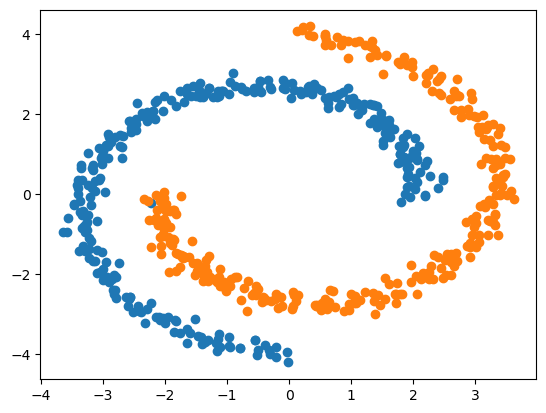

Signature: worst_case_blob(num_samples, delta=5)
Docstring:
Generates a single blob.

:param num_samples: number of samples to create in the blob
:param delta:
:return: X,  (num_samples, 2) matrix of 2-dimensional samples
         Y,  (num_samples, ) vector of "true" cluster assignment
File:      c:\users\jean-\desktop\cours ensae\3a ensae\mva\graph in ml\spectral_clustering\generate_data.py
Type:      function

In [4]:
# Example

for fn in [two_moons]:  #  try also [worst_case_blob, point_and_circle, blobs]
    X, Y = fn(num_samples=600)
    plot_clusters(X, Y, fignum=str(fn))
    
# You can check the documentation of each function to see the optional parameters, e.g.:
worst_case_blob?

## Building similarity graph

In [5]:
def build_similarity_graph(X, var=1.0, eps=0.0, k=0):
    """
    TO BE COMPLETED.

    Computes the similarity matrix for a given dataset of samples. 
    If k=0, builds epsilon graph. 
    Otherwise, builds kNN graph.

    Parameters
    ----------
    X : numpy array
        (n x m) matrix of m-dimensional samples
    var : double 
        the sigma value for the exponential function, already squared
    eps : double
        threshold for epsilon graphs
    k : int
        The number of neighbours k for k-nn. If zero, use epsilon-graph

    Returns
    -------
        W: (n x n) dimensional matrix representing the weight matrix of the graph
    """
    n = X.shape[0]
    W = np.zeros((n, n))

    """
    Build similarity graph, before threshold or kNN
    similarities: (n x n) matrix with similarities between all possible couples of points.
    The similarity function is d(x,y)=exp(-||x-y||^2/(2*var))
    """
  
    similarities = np.exp(
        -np.linalg.norm(X[None, :, :] - X[:, None, :], axis=-1) ** 2 / (2 * var)
    )

    # If epsilon graph
    if k == 0:
        """
        compute an epsilon graph from the similarities             
        for each node x_i, an epsilon graph has weights             
        w_ij = d(x_i,x_j) when w_ij >= eps, and 0 otherwise          
        """
        mask = similarities >= eps
        W[mask] = similarities[mask]
        

    # If kNN graph
    elif k != 0:
        """
        compute a k-nn graph from the similarities                   
        for each node x_i, a k-nn graph has weights                  
        w_ij = d(x_i,x_j) for the k closest nodes to x_i, and 0     
        for all the k-n remaining nodes                              
        Remember to remove self similarity and                       
        make the graph undirected                                    
        """
        pass
        np.fill_diagonal(similarities, 0)
        for j in range(n):
            knn = np.argsort(similarities[j])[::-1][:k]
            W[j, knn] = similarities[j, knn]
        # for a symmetric W
        W = np.maximum(W,W.T)


    return W


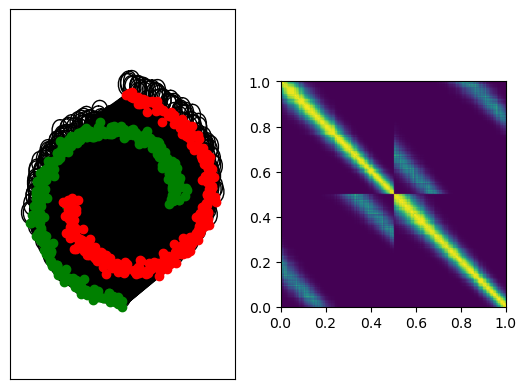

In [6]:
# Example

W = build_similarity_graph(X)
W[0, 599] = 1    # add two placeholder edges to reproduce example picture
W[10, 500] = 1   # 


plot_graph_matrix(X, Y, W)  # shows the graph and the visualization of W

## Computing the Laplacian

In [7]:
def build_laplacian(W, laplacian_normalization='unn'):
    """
    Compute graph Laplacian.

    Parameters
    ----------
    W : numpy array
        Adjacency matrix (n x n)
    laplacian_normalization : str
        String selecting which version of the laplacian matrix to construct.
            'unn':  unnormalized,
            'sym': symmetric normalization
            'rw':  random-walk normalization   

    Returns
    -------
    L: (n x n) dimensional matrix representing the Laplacian of the graph
    """
    L = np.zeros(W.shape)
    D = np.diag((np.sum(W,axis=1)))
    L = D-W

    if laplacian_normalization == 'unn':
        pass

    elif laplacian_normalization == 'sym':
        sqrt_D = matrix_power(D,-0.5)
        L =  sqrt_D @ L @ sqrt_D
    
    elif laplacian_normalization == 'rw':
        D_inv = matrix_power(D,-1)
        L = D_inv @ L


    
    # for example (unnormalized): L = D - W
    return L

## Clustering

In [8]:
def spectral_clustering(L, chosen_eig_indices=None, num_classes=2):
    """
    Parameters
    ----------
    L : numpy array
        Graph Laplacian (standard or normalized)
    choosen_eig_indices : list or None
        Indices of eigenvectors to use for clustering. 
        If None, use adaptive choice of eigenvectors.
    num_classes : int 
        Number of clusters to compute (defaults to 2)


    Returns
    -------
    Y : numpy array (num_samples, )
        Cluster assignments
    """

    """
    Use the function scipy.linalg.eig or the function scipy.sparse.linalg.eigs to compute:
    U = (n x n) eigenvector matrix           (sorted)
    E = (n x n) eigenvalue diagonal matrix   (sorted)
    """
    Y = np.zeros(L.shape[0])
    E, U = scipy.linalg.eig(L)
    E = np.real(E)
    U = np.real(U)

    sorted_indices = np.argsort(E)
    E = np.diag(E[sorted_indices])
    U = U[:,sorted_indices]

    """
    compute the clustering assignment from the eigenvectors        
    Y = (n x 1) cluster assignments in [0,1,...,num_classes-1]                   
    """

    if chosen_eig_indices is None:
        indices = range(num_classes)
    else:
        indices = chosen_eig_indices
    
    U = U[:,indices]
    kmeans = KMeans(n_clusters = num_classes, random_state = 42, n_init = 10)
    Y = kmeans.fit_predict(U)
    return Y

c:\Users\jean-\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\jean-\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


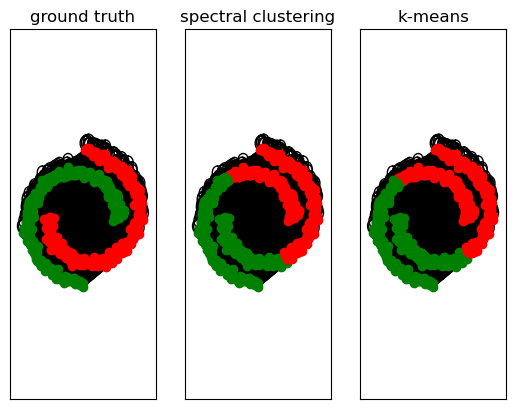

In [9]:
# Example

num_classes = 2
L = build_laplacian(W)
Y_rec = spectral_clustering(L, chosen_eig_indices=[1, 2], num_classes=num_classes)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L, Y_rec, KMeans(num_classes).fit_predict(X))

## Parameter sensitivity 

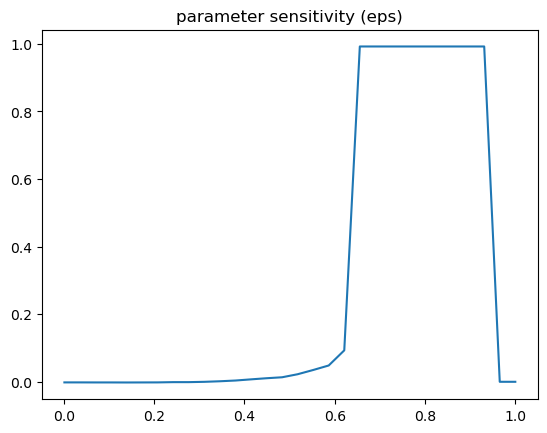

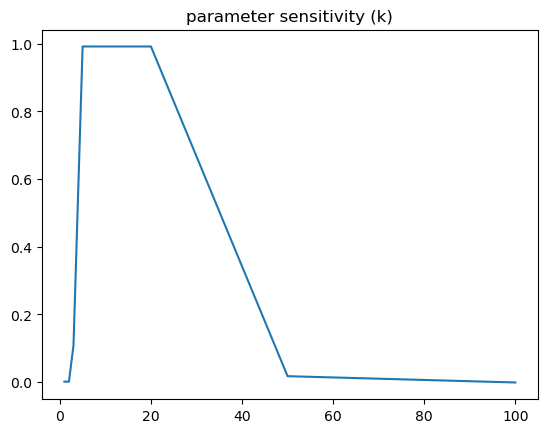

In [10]:
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

def parameter_sensitivity():
    """
    TO BE COMPLETED.

    A function to test spectral clustering sensitivity to parameter choice.
    """
    # the number of samples to generate
    num_samples = 500
    X, Y = two_moons(num_samples, 1, 0.02)
    num_classes = len(np.unique(Y))

    for parameter_type in ['eps','k']:

        """
        Choose parameters
        """
        var = 1  #(0.1*np.std(X))**2  # exponential_euclidean's sigma^2
        laplacian_normalization = 'unn'
        chosen_eig_indices = None

        """
        Choose candidate parameters
        """
        if parameter_type == 'k':
            parameter_candidate = [1, 2,3,5,10,20,50,100]  # the number of neighbours for the graph (if 'k')
            parameter_performance = []

            for parameter in parameter_candidate:
                # Generate data
                
                W = build_similarity_graph(X, var, eps = 0, k= parameter)
                L = build_laplacian(W, laplacian_normalization)

                Y_rec = spectral_clustering(L, chosen_eig_indices, num_classes)

                parameter_performance += [skm.adjusted_rand_score(Y, Y_rec)]

            plt.figure()
            plt.plot(parameter_candidate, parameter_performance)
            plt.title(f'parameter sensitivity ({parameter_type})')
            plt.show()

        
        else:
            k = 0
            parameter_candidate = np.linspace(0.001,1,30)
                                    # or the epsilon threshold (if 'eps')

            parameter_performance = []

            for parameter in parameter_candidate:
                # Generate data
                
                W = build_similarity_graph(X, var,parameter, k)
                L = build_laplacian(W, laplacian_normalization)

                Y_rec = spectral_clustering(L, chosen_eig_indices, num_classes)

                parameter_performance += [skm.adjusted_rand_score(Y, Y_rec)]

            plt.figure()
            plt.plot(parameter_candidate, parameter_performance)
            plt.title(f'parameter sensitivity ({parameter_type})')
            plt.show()



parameter_sensitivity()
        

## Image segmentation

In [50]:
def image_segmentation(
                    var = 1,
                    k = 15,
                    laplacian_normalization = 'unn',
                    chosen_eig_indices = [1,2,3,4,5],
                    num_classes = 5,
                    input_img='four_elements.bmp'):
    """
    TO BE COMPLETED

    Function to perform image segmentation.

    :param input_img: name of the image file in /data (e.g. 'four_elements.bmp' or 'fruit_salad.bmp')
    """
    filename = os.path.join('data', input_img)

    X = io.imread(filename)
    X = (X - np.min(X)) / (np.max(X) - np.min(X))

    im_side = np.size(X, 1)
    Xr = X.reshape(im_side ** 2, 3)
    """
    Y_rec should contain an index from 0 to c-1 where c is the     
     number of segments you want to split the image into          
    """

    """
    Choose parameters 
    """
    

    W = build_similarity_graph(Xr, var=var, k=k)
    L = build_laplacian(W, laplacian_normalization)
    Y_rec = spectral_clustering(L, chosen_eig_indices, num_classes=num_classes)

    plt.figure()

    plt.subplot(1, 2, 1)
    plt.imshow(X)

    plt.subplot(1, 2, 2)
    Y_rec = Y_rec.reshape(im_side, im_side)
    plt.imshow(Y_rec)

    plt.show()

   

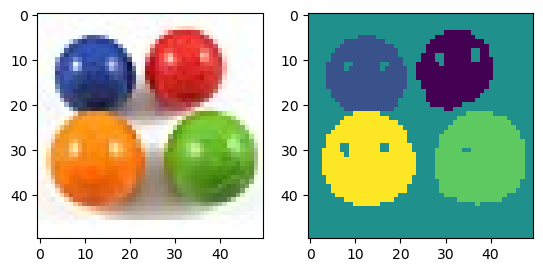

In [12]:
image_segmentation()

# Questions

### Q1.1: What is the purpose of the option parameter in `worst_case_blob`?

In the worst_case_blob function, we have X[-1] = [np.max(X) + delta, 0]. 
This parameter is used to create an outlier that is purposely far from the rest of the blob. Delta controls how far this outlier is from the rest of the cluster. The point of this parameter is that clustering algorithms are sensitive to outliers, so playing with this parameter allows to see how the clustering algorithms react to outliers. 

### Q1.2: While varying the parameter of `worst_case_blob`, try to select a value of $\epsilon$ that keeps the graph connected (the function `min_span_tree` can help you). What happens? Can you tell when it is a bad idea to use this approach?

In [55]:
min_span_tree?

Signature: min_span_tree(W)
Docstring:
:param W: (n x n) adjacency matrix representing the graph
:return: T: (n x n) matrix such that T[i,j] = True if the edge (i, j) is in the min spanning tree, and
            T[i, j] = False otherwise
File:      c:\users\jean-\desktop\cours ensae\3a ensae\mva\graph in ml\spectral_clustering\utils.py
Type:      function

A graph with n nodes is connex iff the minimum spanning tree has n-1 edges. We can use the min_span_tree function to exploit this property and answer the question.

In [69]:
deltas = np.arange(1,10,1)
epsilons = np.linspace(0.000001,1,50)

for delta_i in deltas:

    X,Y = worst_case_blob(num_samples = 500, delta = delta_i)
 
    for epsi in epsilons[::-1]: 

        W = build_similarity_graph(X, var=1.0, eps=epsi, k=0)
        T = min_span_tree(W)
       
        if T.sum() == X.shape[0] - 1:
            print(f'for delta = {delta_i} the parameter epsilon = {epsi} is the largest value in the range np.linspace(0.1,10,50) that keeps the graph connected')
            break
    
    else:
        print(f'for delta = {delta_i} no parameter in the range np.linspace(0.1,10,50) keeps the graph connected')

for delta = 1 the parameter epsilon = 0.5714290000000001 is the largest value in the range np.linspace(0.1,10,50) that keeps the graph connected
for delta = 2 the parameter epsilon = 0.10204171428571429 is the largest value in the range np.linspace(0.1,10,50) that keeps the graph connected
for delta = 3 the parameter epsilon = 1e-06 is the largest value in the range np.linspace(0.1,10,50) that keeps the graph connected
for delta = 4 the parameter epsilon = 1e-06 is the largest value in the range np.linspace(0.1,10,50) that keeps the graph connected
for delta = 5 the parameter epsilon = 1e-06 is the largest value in the range np.linspace(0.1,10,50) that keeps the graph connected
for delta = 6 no parameter in the range np.linspace(0.1,10,50) keeps the graph connected
for delta = 7 no parameter in the range np.linspace(0.1,10,50) keeps the graph connected
for delta = 8 no parameter in the range np.linspace(0.1,10,50) keeps the graph connected
for delta = 9 no parameter in the range np.lin

For delta>5, we can't get a connected graph even with a very small value of the parameter epsilon, set at 1e-6.

When there are some outliers in the graph, if we try to connect outliers to at least another point, then all the non-outliers points will be connected, which will result in a fully connected connex graph: this is not ideal in terms of space and time complexity, the Laplacian will not reflect the true local geometry of the data, so spectral clustering won't work properly. 

### Q1.3: Is it important to build a connected graph? Compare k-NN to $\epsilon$-graphs with respect to the difficulty of building a connected graph.

Yes, it is important to build connected graphs on data with outliers: as seen in class, the multiplicity of eigenvalue zero of the laplacian is equal to the number of components of the graph. As a result, if there is an outlier that is not connected to the cluster it should belong to, this can be a problem when performing spectral clustering because the outlier will be associated to an eigenvalue on it's own: this eigenvalue will zero and this will create a cluster made only of this outlier.

It is easier to build a connected KNN graph than a connected \espilon graph because in a KNN graph, it is not possible to have an isolated outlier that forms a connected component by itself, as it will be connected to K neighbors. 

### Q2.1: Build a graph starting from the data generated in `blobs`, and keep the graph connected. Use `spectral_clustering` to cluster the data. Motivate your choice on which eigenvectors to use and how you computed the clustering assignments from the eigenvectors. Now compute a similar clustering using the built-in k-means and compare the results.

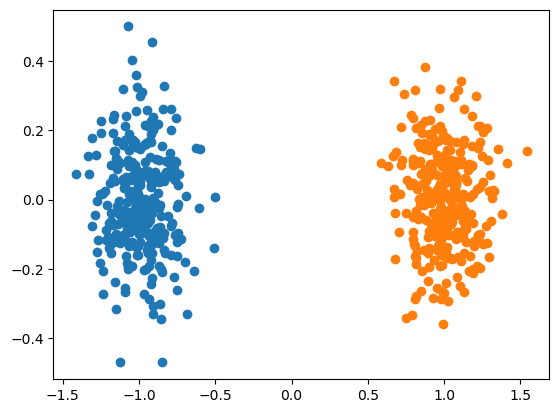

Signature: blobs(num_samples, n_blobs=2, blob_var=0.15, surplus=0)
Docstring:
Creates N gaussian blobs evenly spaced across a circle.

:param num_samples: number of samples to create in the dataset
:param n_blobs:      how many separate blobs to create
:param blob_var:    gaussian variance of each blob
:param surplus:     number of extra samples added to first blob to create unbalanced classes
:return: X,  (num_samples, 2) matrix of 2-dimensional samples
         Y,  (num_samples, ) vector of "true" cluster assignment
File:      c:\users\jean-\desktop\cours ensae\3a ensae\mva\graph in ml\spectral_clustering\generate_data.py
Type:      function

In [70]:
blobs?
X, Y = blobs(num_samples=600)
plot_clusters(X, Y)

In [74]:
build_similarity_graph(X, var=1.0, eps=0.0, k=50)


k_list = np.arange(280,310,1)
for knn in k_list: 

    W = build_similarity_graph(X, var = 1, eps = 0, k = knn)
    T = min_span_tree(W)
    
    if T.sum() == X.shape[0] - 1:
        print(f'the smallest value of k that allows to get a connected graph is {knn}')
        break

else:
    print(f'for delta = {delta_i} no parameter in the range np.linspace(0.1,10,50) keeps the graph connected')

the smallest value of k that allows to get a connected graph is 300


The data is composed of 2 blobs, each blob is made of 300 datapoints and each blob is very far from the other. As shown by the code above, to get a fully connected graph, we need to build a KNN graph with 300 neighbors, so that each point within a blob is connected to the 299 other points in the blob AND to the point from the other blob that is the closest.

Since we built the graph to be fully connected, the first eigenvalue will be equal to zero, and the multiplicity of the eigenvalue zero will be 1. As a result, we want to consider the second eigenvector $V_2$ (the eigenvector indexed by 1), as it will be associated with the second eigenvalue $\lambda_2$, which won't be zero. When plotting the data, it is obvious that we want to do 2 clusters so we only consider the second eigenvector. 

The function that we coded will then run a K-means algorithm on the components of this second eigenvector $V_2$, and for any $i \in \{1,...,600\}$, if the i-th component $V_{2,i}$ is associated to the first cluster, then the datapoint $i$ will be in the first cluster, while if the i-th component $V_{2,i}$ is associated to the second cluster, then the datapoint $i$ will be in the second cluster.

Finally, as shown below, we get the same results when running K-means with K=2 clusters directly on the dataset X. 

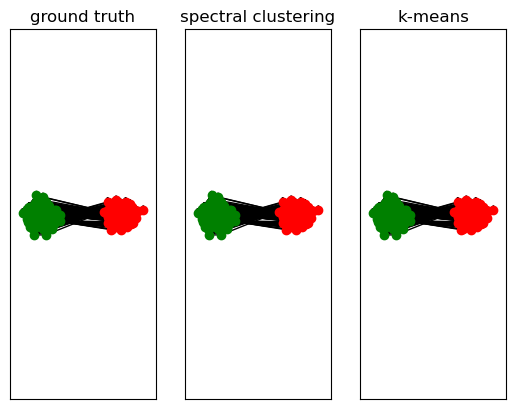

In [ ]:
W = build_similarity_graph(X, var = 1, eps = 0, k = 300)
L = build_laplacian(W, laplacian_normalization='unn')
spectral_clustering(L, chosen_eig_indices=[1], num_classes=2)

Y_rec = spectral_clustering(L, chosen_eig_indices=[1], num_classes=2)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L, Y_rec, KMeans(2).fit_predict(X))

### Q2.2: Build a graph starting from the data generated in `blobs`, but this time make it so that the two components are separated. How do you choose which eigenvectors to use in this case? Motivate your answer.

To get a graph such that the two components are separated, we just need to reduce the number of neighbors: I have set k = 10 arbitrarily. 

This time, since there are two components, the multiplicity of eigenvalue zero will be two, so the two first eigenvectors will be associated to eigenvalue zero. As a result, we want to consider the two first eigenvectors and run K-means on these two first eigenvectors to properly identify two separate clusters associated with these two separated components.

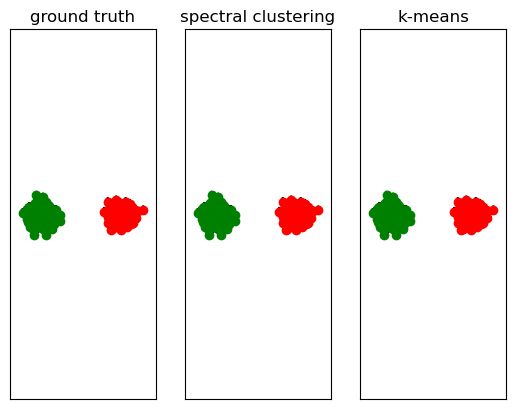

In [94]:
W = build_similarity_graph(X, var = 1, eps = 0, k = 10)
L = build_laplacian(W, laplacian_normalization='unn')
spectral_clustering(L, chosen_eig_indices=[0,1], num_classes=2)

Y_rec = spectral_clustering(L, chosen_eig_indices=[0,1], num_classes=2)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L, Y_rec, KMeans(2).fit_predict(X))

### Q2.3: In the function spectral_clustering, implement an automatic strategy to choose the eigenvectors to use for clustering, when chosen_eig_indices=None. Explain your strategy. Generate a dataset with 4 blobs and test your function. What happens when the variance of the blobs increase?

As shown in the two previous questions:
- if the graph is separated in k separated components, the multiplicity of the eigenvalue zero will be k, and we want to do KMeans on the k first eigenvectors. 
- if the graph is fully connected, the multiplicity of the eigenvalue zero will be 1, and then we consider the k-1 next eigenvectors and we run KMeans on the k-1 next eigenvectors. However, it won't change anything to run Kmeans on the k-1 next eigenvectors or on the k first eigenvectors: indeed, the first eigenvector will be constant and composed only of ones so it won't be used by the KMeans algorithm to cluster the data. 

As a result, in any case, we want to consider the k first eigenvectors if we want to get k clusters.

As shown in the code below, we can see that this approach works well when the variance of the blobs is small. However, if the variance increases, it starts to work terribly. Indeed, if variance increases, the components are not separated anymore and the 4 labels in the ground truth are spread increasingly homogenously in the space and do not form clusters anymore. So it becomes impossible for the algorithm to separate the data in 4 clusters that are aligned with ground truth.

In [97]:
def spectral_clustering(L, chosen_eig_indices=None, num_classes=2):
    """
    Parameters
    ----------
    L : numpy array
        Graph Laplacian (standard or normalized)
    choosen_eig_indices : list or None
        Indices of eigenvectors to use for clustering. 
        If None, use adaptive choice of eigenvectors.
    num_classes : int 
        Number of clusters to compute (defaults to 2)


    Returns
    -------
    Y : numpy array (num_samples, )
        Cluster assignments
    """

    """
    Use the function scipy.linalg.eig or the function scipy.sparse.linalg.eigs to compute:
    U = (n x n) eigenvector matrix           (sorted)
    E = (n x n) eigenvalue diagonal matrix   (sorted)
    """
    Y = np.zeros(L.shape[0])
    E, U = scipy.linalg.eig(L)
    E = np.real(E)
    U = np.real(U)

    sorted_indices = np.argsort(E)
    E = np.diag(E[sorted_indices])
    U = U[:,sorted_indices]

    """
    compute the clustering assignment from the eigenvectors        
    Y = (n x 1) cluster assignments in [0,1,...,num_classes-1]                   
    """

    if chosen_eig_indices is None:
        indices = np.arange(num_classes)
    else:
        indices = chosen_eig_indices
    
    U = U[:,indices]
    kmeans = KMeans(n_clusters = num_classes, random_state = 42, n_init = 10)
    Y = kmeans.fit_predict(U)
    return Y

variance of the blobs: 0.1


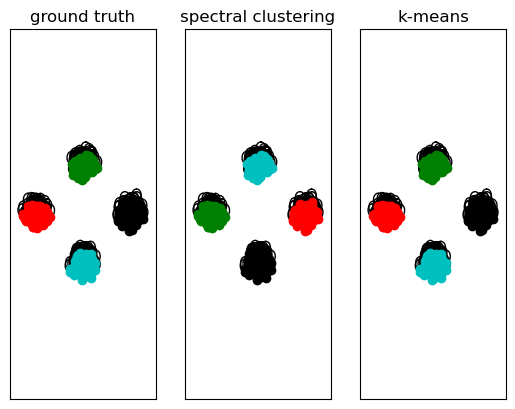

variance of the blobs: 0.3


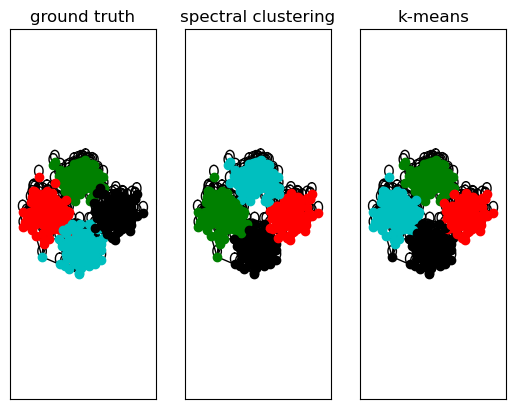

variance of the blobs: 0.5


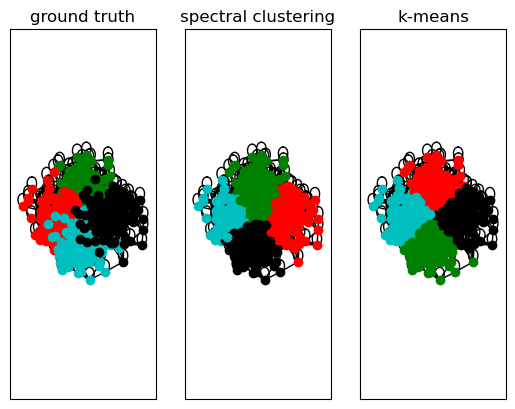

variance of the blobs: 0.7


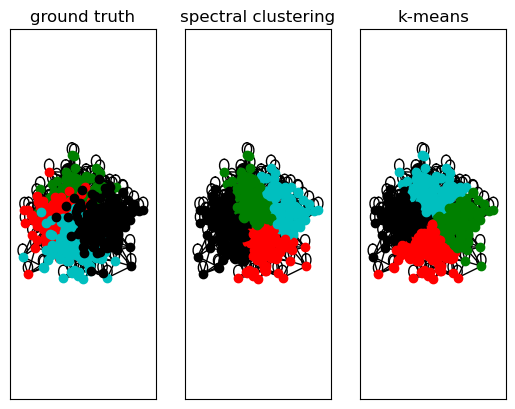

variance of the blobs: 0.9


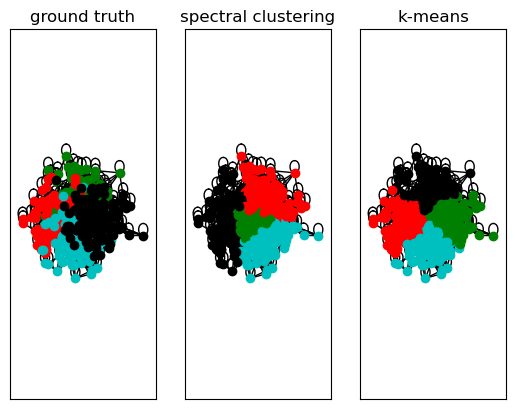

variance of the blobs: 1.1


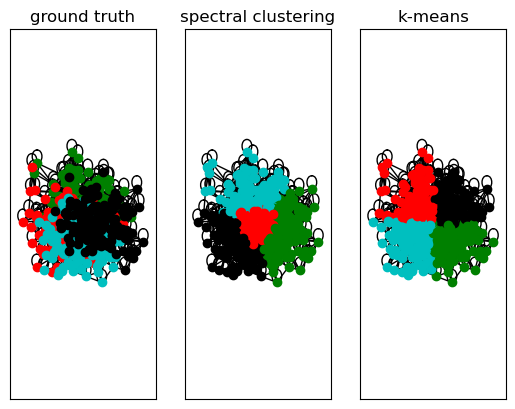

variance of the blobs: 1.3


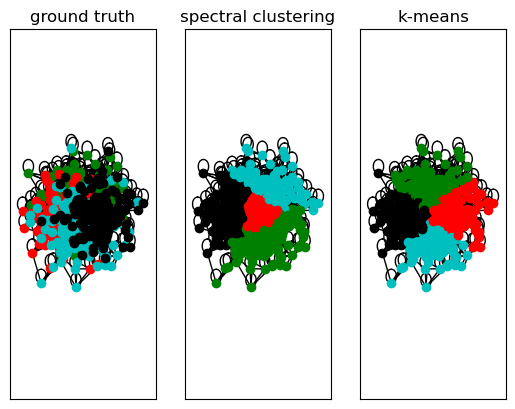

variance of the blobs: 1.5


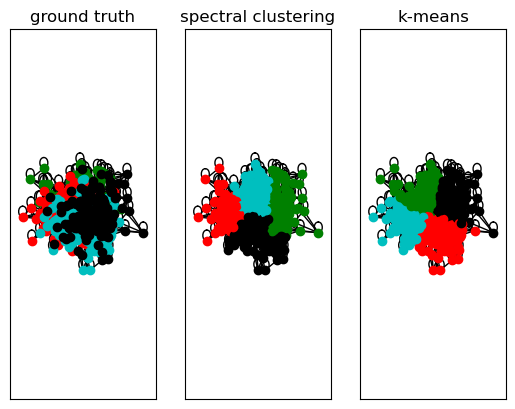

variance of the blobs: 1.7


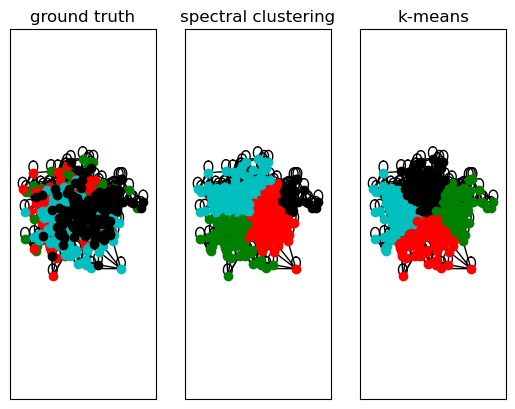

variance of the blobs: 1.9


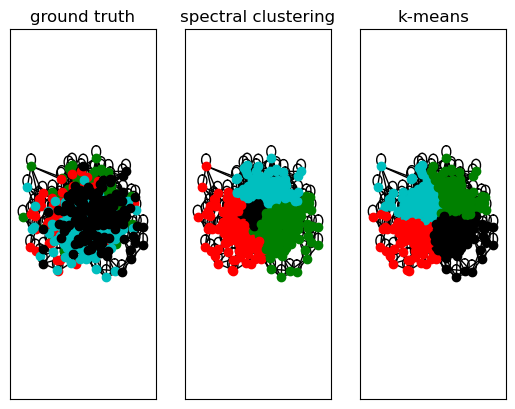

In [104]:
for var in np.arange(0.1,2,0.2):
    print("variance of the blobs:",np.round(var,1))
    X, Y = blobs(num_samples=600, n_blobs=4, blob_var=var)
    W = build_similarity_graph(X, var = 1, eps = 0, k = 5)
    L = build_laplacian(W, laplacian_normalization='unn')
    spectral_clustering(L, chosen_eig_indices=None, num_classes=4)

    Y_rec = spectral_clustering(L, chosen_eig_indices=None, num_classes=4)

    # Plot results, comparing to KMeans
    plot_clustering_result(X, Y, L, Y_rec, KMeans(4).fit_predict(X))



### Q2.4: When you built the cluster assignment, did you use thresholding, k-means or both? Do you have any opinion on when to use each?

I used Kmeans only to build the cluster assignment. In my understanding:
- it makes sense to use thresholding and to separate datapoints in clusters only if we want to get 2 clusters: in this case, we can simply look at the second eigenvector $V_2$, and for each datapoint i, we assign it to cluster A if $V_{2,i}>0$, and we assign it to cluster B if $V_{2,i}<0$. If there are two separate clusters, from a computational perspective, it may be better to use thresholding because it has a lower time complexity (O(N)) than K-means.
- However, this approach do not work anymore if there are more than 2 classes: in this case we need to use K-means. This will be more costly but we need to use it in this case. 
- Besides, if data is noisy, even if there are only two classes, it may be better to use K-means because the threshold value 0 is not anymore the best value to separate the data in two classes. 

### Q2.5: Generate `two_moons` data and compare spectral clustering to k-means. Do you notice any difference? Taking into consideration the graph structure, can you explain them?

We get much better results with spectral clustering than with K-means: spectral clustering allows to identify two clusters that are very similar, if not identical, to ground truth. However K-means works terribly. 

The two-moon data has a very specific structure and it is especially relevant to model it as a graph because it will naturally yield two separated components with the shape of two moons (provided that we choose an appropriate number of neighbors when building the graph). As a result, when running spectral clustering, we will benefit from this specific graph structure with two separate components. It will be easy to create two clusters out of these two separate components with spectral clustering. 

K-means works poorly because it relies on the assumption that clusters are convex sets and it uses the euclidean distance with respect to a centroid. Here the clusters are not convex, hence the poor results.

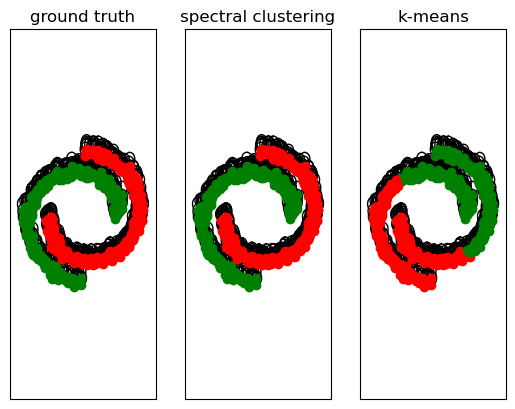

In [109]:
W = build_similarity_graph(X, var = 1, eps = 0, k = 10)
L = build_laplacian(W, laplacian_normalization='unn')
spectral_clustering(L, chosen_eig_indices=None, num_classes=2)

Y_rec = spectral_clustering(L, chosen_eig_indices=[0,1], num_classes=2)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L, Y_rec, KMeans(2).fit_predict(X))



### Q2.6: Generate `point_and_circle` data and compare spectral clustering using the normal Laplacian and the random-walk regularized Laplacian. Do you notice any difference? Taking into consideration the graph structure, can you explain them?

When I build a graph that do not connect the circle and the point component, i.e., when I choose a small number of neighbors k to build the knn graph, I similar results when using either the unnormalized laplacian or the random-walk regularized laplacian. 

However, if I increase the number of neighbors k when building the graph, i.e. when the two components become connected, then I observe that the random-walk regularized laplacian works much better than the unnormalized laplacian, as shown below. This is because:
- when doing spectral clustering on the unnormalized laplacian, we approximate the RatioCut problem, which creates 2 clusters with the same number of points. This is not adapted to the point and circle data, because the circle component contains much more datapoints than the point component. 
- when doing spectral clustering on the random walk regularized laplacian, we approximate the NormalizedCut problem, which creates 2 clusters with the same volume/density. This is perfectly adapted to the point and circle data, because both components have a similar volume.  

### With the unnormalized laplacian:

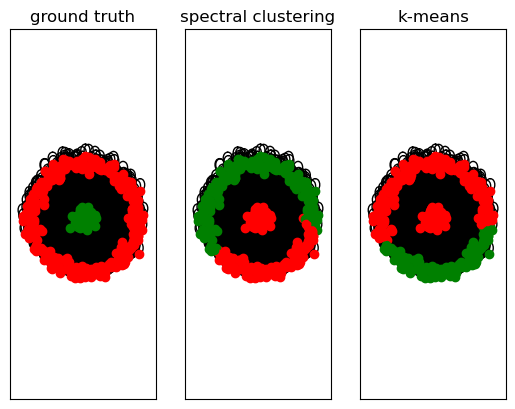

In [38]:

X, Y = point_and_circle(num_samples=600)
W = build_similarity_graph(X, var = 1, eps = 0, k = 100)
L_un = build_laplacian(W, laplacian_normalization='unn')
Y_rec = spectral_clustering(L_un, chosen_eig_indices=[0,1], num_classes=2)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L_un, Y_rec, KMeans(2).fit_predict(X))

### with the random walk regularized laplacian:

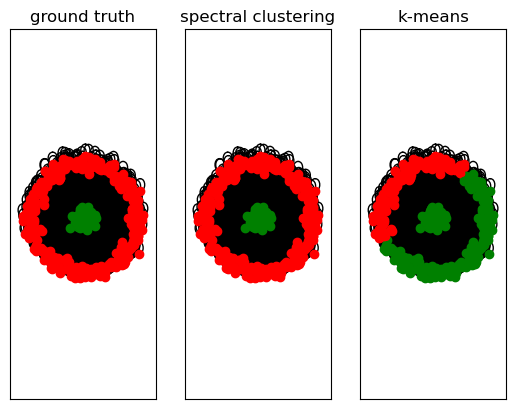

In [39]:

L_rw = build_laplacian(W, laplacian_normalization='rw')
Y_rec = spectral_clustering(L_rw, chosen_eig_indices=[0,1], num_classes=2)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L_rw, Y_rec, KMeans(2).fit_predict(X))

### Q2.7: Using the function parameter_sensitivity, comment on the stability of spectral clustering when varying $\epsilon$ or k. 

The sensitivity analysis was run on the two moons data. 

When $\epsilon$ is small, or when $k$ is large, we keep too many edges in the graph, which makes the graph too dense and fully connected although it should not be fully connected (we should have two components, i.e. the full moons). This results in poor clustering results and a low adjusted random score (ARI). 

When $\epsilon$ increases or $k$ decreases, we reduce the number of edges in the graph, which increases the ARI. With values of $\epsilon$ between 0.7 and 0.9, or with values of with values of $k$ between 10 and 20, the ARI is maximized as we keep an optimal number of edge which allows to obtain excellent results when performing spectral clustering. 

When $\epsilon$ increases too much and gets close to 1, or when $k$ decreases too much and gets close to zero, the ARI drops to 0: in this case we don't keep enough edges in the graph (we may not even keep any edge): the graph will not be dense, resulting in terrible clustering results. 



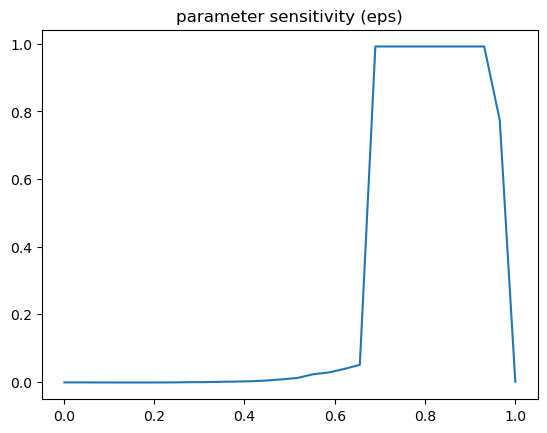

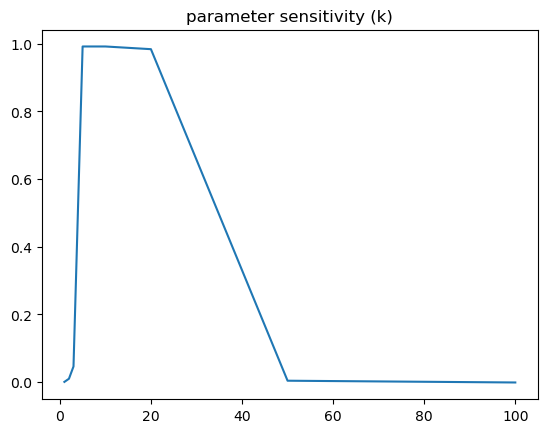

In [40]:
parameter_sensitivity()

### Q2.8: If we did not have access to "true" labels, how could we evaluate the clustering result (or what should we not use as evaluation)?

First, I would plot the graph and color the two associated clusters on the graph, to see if the clustering results make sense from a visual perspective. If clusters correspond to separated components, the results are probably good. If not, and if a cluster corresponds to some parts of several separates components, then the results are likely not great. 

I would also plot the eigenvalues of the laplacian and check if there is an eigengap in the laplacian spectrum: if there is no gap between the eigenvalues associated with eigenvectors used to do spectral clustering and the other eigenvalues, then the clustering results may not be good. 

We could also perform a stability analysis and verify if the clustering results remain similar if we slightly modify the data or the graph parameters. 

### Q3.1: Complete all the code necessary, and cluster the `four_elements` and `fruit_salad` images in the data folder and include here some images of the clustering.  Explain your design choices in the overall pipeline (e.g. which graph, which pre-processing...) and how you think they impact the results you are seeing. Report also at least one failure mode for the algorithm.

For the four_elements image: 
- I chose to keep the unnormalized laplacian because the 4 balls have approximately the same size, i.e. they are each represented by approximately the same number of datapoints, so we want to get 4 clusters with similar weights. Hence it is more relevant to use the unnormalized laplacian as it approximates RatioCut. 
- reducing the number of neighbors allows to reduce the misclassification of bright reflections on the balls (the dark blue dots on the balls), maybe because there is less edges between white pixels representing these bright reflections and pixels from the white background. I iteratively reduced the number of neighbors k until the clustering stopped working, which led to the value k = 9. When decreasing k to k = 9, I managed to get no misclassification on the lower right ball, and I reduced the size of the spots that are misclassified on the other balls. 
- since there are 4 balls and one background, we want to choose 5 classes, otherwise we won't manage to cluster every part of the image properly. 
- I did not keep the first eigenvector as it is associated to eigenvalue zero and the graph is connected, so I used the 5 next eigenvectors. 
- A failure in the classification of the algorithm is that there are still some bright reflection spots on the balls that are not properly classified.

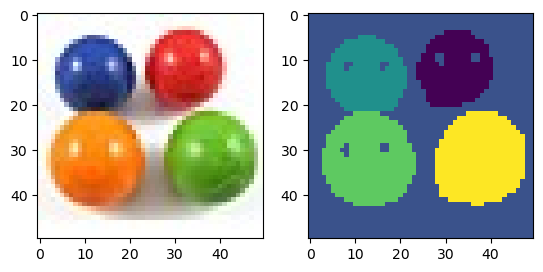

In [ ]:
image_segmentation(var = 0.5,
                    k = 9,  #10 
                    laplacian_normalization = 'unn',
                    chosen_eig_indices = [1,2,3,4,5],
                    num_classes = 5,
                    input_img='four_elements.bmp')

For the fruit_salad image: 
- I chose to use the random walk regularized laplacian because this time, the  clusters that we want to identify don't have the same size in terms of pixels/datapoints so using the unnormalized laplacian to approximate RatioCut is not relevant anymore.  
- I also reduced iteratively the number of neighbors to reduce misclassification of some spots (bright reflection spots and ends of fruit slices) until classification stopped working. For k = 17 neighbors I had good results and this allowed me to reduce the missclassification of some parts of the image, for k =16, classification did not work anymore and the fruit was identified as a whole cluster.
- there are 3 fruits and one background so I chose to use 4 classes. Similarly, I did not use the first eigenvector associated with eigenvalue zero as it did not bring any information, so I used the 4 next eigenvectors. 
- A failure of the clustering procedure is that the ends of fruit slices, especially orange slices, are misclassified: these orange slice ends tend toward yellow, which is close to the green of a green apple, hence the classification error. 

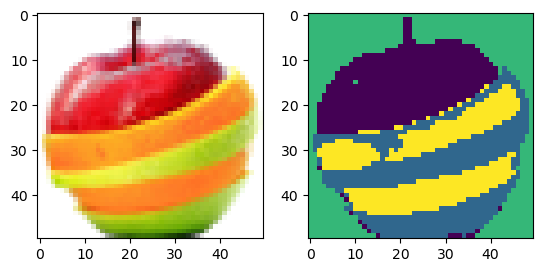

In [100]:
image_segmentation(var = 0.5,
                    k = 17, #25    #k = 6,
                    laplacian_normalization = 'rw',
                    chosen_eig_indices = [1,2,3,4],
                    num_classes = 4,
                    input_img='fruit_salad.bmp')

### Q3.2: A full graph built between the pixels of a 50 × 50 image corresponds to $50^2$ nodes. Solving the full eigenvalue problem in this case would scale in the order of $2^{34}$ . Even on weak hardware this takes only seconds to minutes. Segmenting a Full HD picture of 1920 × 1080 would scale in the order of $2^{64}$ (about a month on a decent machine). Beyond that, the large picture would require to store in memory a graph over millions of nodes. A full graph on that scale requires about 1TB of memory. Can you think two simple techniques to reduce the computational and occupational cost of Spectral Clustering?

- A first solution is use image downsampling to reduce the definition of the image, i.e. to reduce the number of pixels used to represent the image. We then perform spectral clustering on the low resolution image, which will be much less computationally costly
- Another solution would be to first run a clustering algorithm on the image to cluster the pixels composing the image in K groups of pixels (K superpixels). Then we can turn our clusterised image into a graph with K nodes and run spectral clustering on this clusterised image. 
- Because the question mentions "full graphs", we can also simply sparisfy the graphs using epsilon thresholding or build a KNN graph, to reduce the number of edges to keep in memory. 




### Q3.3: Choose a larger image of your choice, and try to implement some of the scalability modifications to run spectral clustering on it. Report some examples of the results you achieve. 

In [175]:
from skimage import io, transform, data

img_large = io.imread("manu.jpg")
target_size = (64, 64) 
img_small = transform.resize(img_large, target_size, anti_aliasing=True)
X_small = img_small.reshape(-1,3)


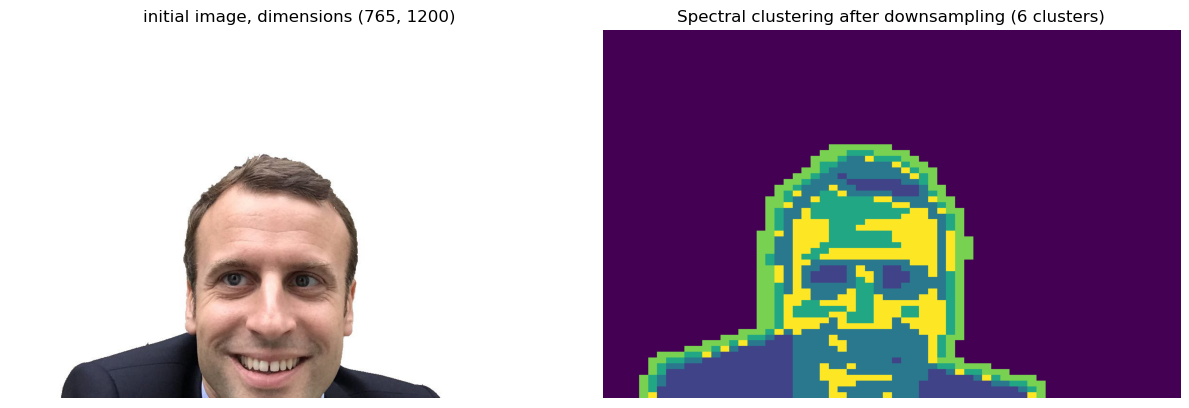

In [176]:
W = build_similarity_graph(X_small, var=0.05, k=11)
L = build_laplacian(W, laplacian_normalization='rw') 
Y_small = spectral_clustering(L, chosen_eig_indices=None, num_classes=6)
mask_small = Y_small.reshape(64,64)
mask_large = transform.resize(mask_small, img_large.shape[:2], order=0, anti_aliasing=False)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_large)
plt.title(f"initial image, dimensions {img_large.shape[:2]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_large)
plt.title(f"Spectral clustering after downsampling (6 clusters)")
plt.axis('off')

plt.tight_layout()
plt.show()

When downsampling the image to size 64x64, we reduce a lot the quality of the image, which necessarly impacts the quality of clustering. Inded, each datapoint becomes a group of pixels, and we can't assign different labels to several pixels within the same datapoint resulting from downsampling. As a result, even after trying many values of parameters when turning the image into a graph and running clustering, the result of our clustering algorithm is far from being perfect: for instance, there is no specific cluster for the mouth of macron in the image above.

However, it is necessary to reduce a lot the quality of the image to save computational time. I tried below to downsample the image to size 128x128 as I hoped that it would yield better clustering results. Since there are more datapoints, we could theoretically do a much better clustering, but the computational time makes it impossible to iteratively try several values of the parameters to improve clustering results: when downsampling the image to size 128x128, it took 34 minutes to output the clustering result below, while it took only 28 seconds to output the clustering result above from a downsampled image with size 64x64.

In [ ]:
target_size = (128, 128) 
img_small = transform.resize(img_large, target_size, anti_aliasing=True)
X_small = img_small.reshape(-1,3)

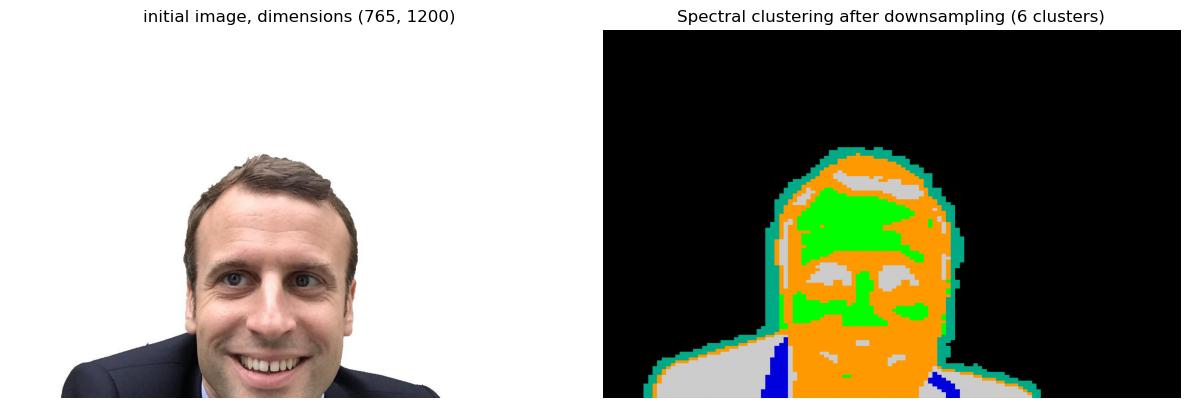

In [174]:
W = build_similarity_graph(X_small, var=0.05, k=11)
L = build_laplacian(W, laplacian_normalization='rw') 
Y_small = spectral_clustering(L, chosen_eig_indices=None, num_classes=6)
mask_small = Y_small.reshape(128,128)
mask_large = transform.resize(mask_small, img_large.shape[:2], order=0, anti_aliasing=False)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_large)
plt.title(f"initial image, dimensions {img_large.shape[:2]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_large)
plt.title(f"Spectral clustering after downsampling (6 clusters)")
plt.axis('off')

plt.tight_layout()
plt.show()